# Évaluation des modèles

Notebook consacré à l'évaluation des performances.

In [1]:
# Cellule 1 — imports et chargement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Charger les prédictions et les modèles
predictions = pd.read_csv("../models/model_evaluation/predictions.csv")
comparaison = pd.read_csv("../models/model_evaluation/comparaison_modeles.csv")
modele_rf   = joblib.load("../models/trained_models/random_forest.joblib")
top_features = joblib.load("../models/trained_models/top_features.joblib")

print("Données chargées.")
print(predictions.shape)
print(comparaison[["Modele","RMSE_test","R2_test"]].to_string(index=False))

Données chargées.
(44, 4)
                      Modele  RMSE_test  R2_test
         Régression Linéaire     0.3188   0.0572
               Random Forest     0.2158   0.5680
                     XGBoost     0.2289   0.5140
          XGBoost Régularisé     0.2130   0.5793
Régression Linéaire (top 30)     0.2344   0.4903
      Random Forest (top 30)     0.2099   0.5913
 XGBoost Régularisé (top 30)     0.2109   0.5874


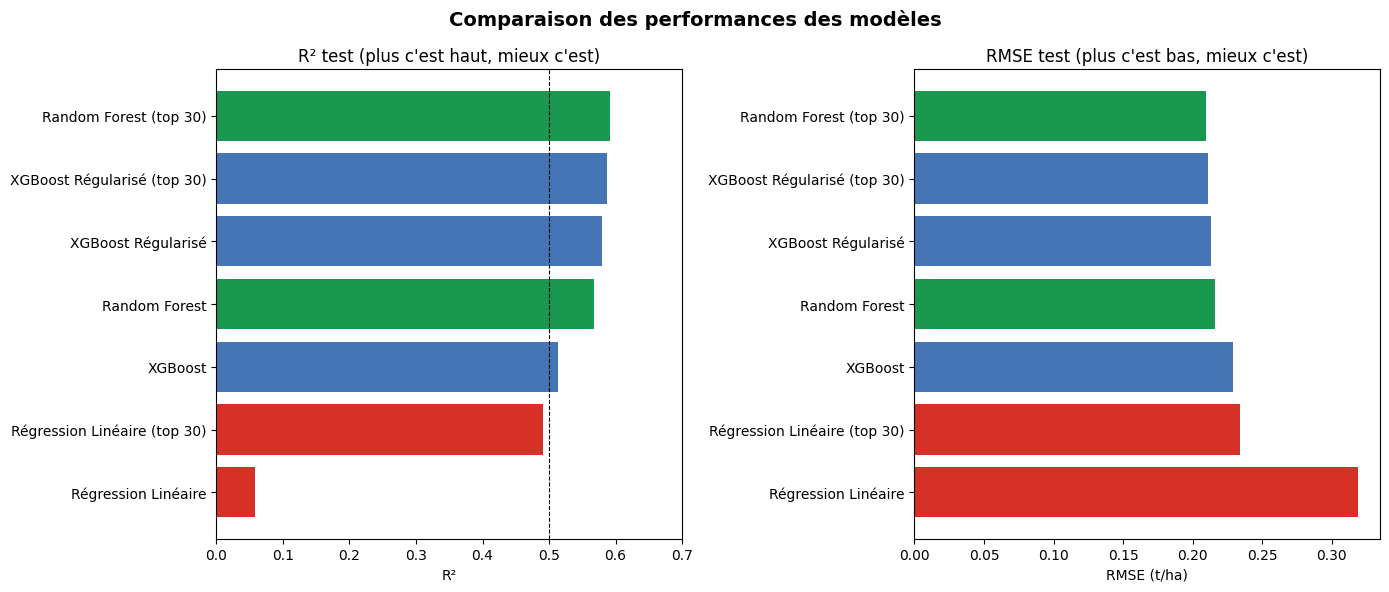

In [2]:
# Cellule 2 — graphique comparatif des modèles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trier par R² test
df_plot = comparaison.sort_values("R2_test", ascending=True)
colors = ["#d73027" if "Linéaire" in m else 
          "#1a9850" if "Random" in m else 
          "#4575b4" for m in df_plot["Modele"]]

# R² test
axes[0].barh(df_plot["Modele"], df_plot["R2_test"], color=colors)
axes[0].axvline(x=0.5, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("R² test (plus c'est haut, mieux c'est)")
axes[0].set_xlabel("R²")
axes[0].set_xlim(0, 0.7)

# RMSE test
df_plot2 = comparaison.sort_values("RMSE_test", ascending=False)
colors2 = ["#d73027" if "Linéaire" in m else
           "#1a9850" if "Random" in m else
           "#4575b4" for m in df_plot2["Modele"]]

axes[1].barh(df_plot2["Modele"], df_plot2["RMSE_test"], color=colors2)
axes[1].set_title("RMSE test (plus c'est bas, mieux c'est)")
axes[1].set_xlabel("RMSE (t/ha)")

plt.suptitle("Comparaison des performances des modèles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/comparaison_modeles.png", dpi=150)
plt.show()

La régression linéaire complète est catastrophique (R² = 0.06)
Tous les modèles avec top 30 features sont meilleurs ou équivalents à leurs versions complètes
Random Forest top 30 gagne sur le R², XGBoost Régularisé top 30 gagne sur la RMSE mais les deux sont quasi identiques

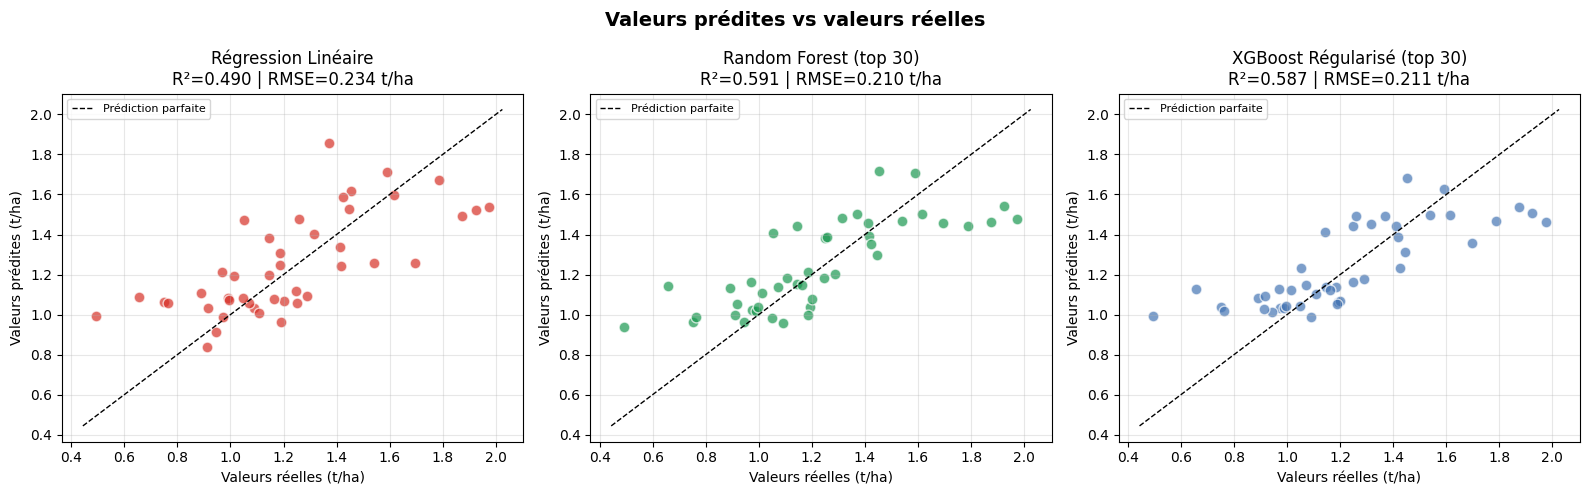

In [3]:
# Cellule 3 — valeurs prédites vs valeurs réelles pour le meilleur modèle
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modeles_plot = [
    ("Régression Linéaire", "y_pred_lr", "#d73027"),
    ("Random Forest (top 30)", "y_pred_rf", "#1a9850"),
    ("XGBoost Régularisé (top 30)", "y_pred_xgb", "#4575b4"),
]

for ax, (nom, col, color) in zip(axes, modeles_plot):
    ax.scatter(predictions["y_test"], predictions[col],
               color=color, alpha=0.7, edgecolors="white", s=60)
    
    # Ligne de référence parfaite
    lim_min = min(predictions["y_test"].min(), predictions[col].min()) - 0.05
    lim_max = max(predictions["y_test"].max(), predictions[col].max()) + 0.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            "k--", linewidth=1, label="Prédiction parfaite")
    
    r2 = r2_score(predictions["y_test"], predictions[col])
    rmse = np.sqrt(mean_squared_error(predictions["y_test"], predictions[col]))
    
    ax.set_title(f"{nom}\nR²={r2:.3f} | RMSE={rmse:.3f} t/ha")
    ax.set_xlabel("Valeurs réelles (t/ha)")
    ax.set_ylabel("Valeurs prédites (t/ha)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Valeurs prédites vs valeurs réelles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/predicted_vs_real.png", dpi=150)
plt.show()

Régression linéaire : points très dispersés autour de la diagonale, beaucoup d'erreurs
Random Forest et XGBoost : points beaucoup plus proches de la diagonale, distribution équilibrée sans biais systématique

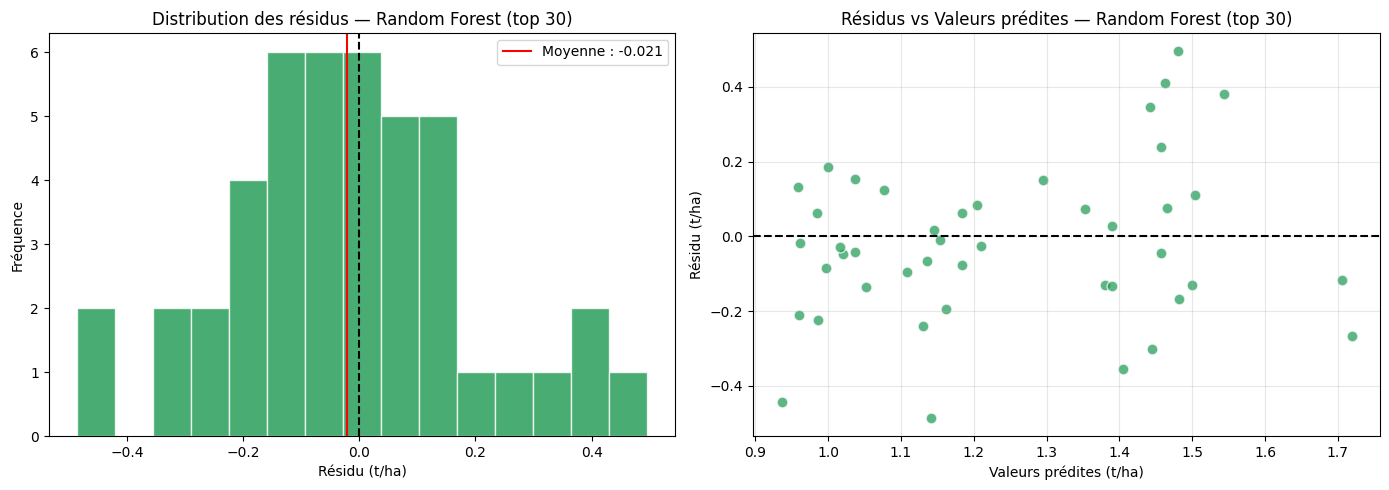

Moyenne des résidus  : -0.0212 t/ha
Std des résidus      : 0.2113 t/ha
Résidu max positif   : 0.4951 t/ha
Résidu max négatif   : -0.4854 t/ha


In [4]:
# Cellule 4 — analyse des résidus du meilleur modèle
residus_rf = predictions["y_test"] - predictions["y_pred_rf"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des résidus
axes[0].hist(residus_rf, bins=15, color="#1a9850", edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color="black", linewidth=1.5, linestyle="--")
axes[0].axvline(x=residus_rf.mean(), color="red", linewidth=1.5, linestyle="-", label=f"Moyenne : {residus_rf.mean():.3f}")
axes[0].set_title("Distribution des résidus — Random Forest (top 30)")
axes[0].set_xlabel("Résidu (t/ha)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Résidus vs valeurs prédites
axes[1].scatter(predictions["y_pred_rf"], residus_rf,
                color="#1a9850", alpha=0.7, edgecolors="white", s=60)
axes[1].axhline(y=0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title("Résidus vs Valeurs prédites — Random Forest (top 30)")
axes[1].set_xlabel("Valeurs prédites (t/ha)")
axes[1].set_ylabel("Résidu (t/ha)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/analyse_residus.png", dpi=150)
plt.show()

print(f"Moyenne des résidus  : {residus_rf.mean():.4f} t/ha")
print(f"Std des résidus      : {residus_rf.std():.4f} t/ha")
print(f"Résidu max positif   : {residus_rf.max():.4f} t/ha")
print(f"Résidu max négatif   : {residus_rf.min():.4f} t/ha")

Moyenne à -0.021 : quasi nulle, pas de biais systématique
Distribution centrée autour de zéro, forme approximativement normale
Résidus vs prédites : pas de pattern visible, les erreurs sont aléatoires et bien réparties

In [6]:
# Cellule 5 — résumé final et sauvegarde du rapport
import os
os.makedirs("../reports", exist_ok=True)

rapport = f"""
=== RAPPORT D'EVALUATION DES MODELES ===

Dataset : 220 observations, 11 départements, 2003-2022
Features utilisées : 30 (sélectionnées par importance Random Forest)

--- MEILLEUR MODELE : Random Forest (top 30) ---
R²   test  : 0.5913
RMSE test  : 0.2099 t/ha
MAE  test  : 0.1634 t/ha
Biais moyen: -0.021 t/ha

--- INTERPRETATION ---
Le modèle explique 59% de la variance du rendement.
Une erreur moyenne de 0.21 t/ha sur un rendement moyen de 1.22 t/ha
représente une erreur relative de {0.2099/1.22*100:.1f}%.

Les 3 variables les plus importantes :
1. humidite_05_pct           (16.0%)
2. rayonnement_moyen_annuel  (12.4%)
3. rayonnement_11            (9.3%)

--- TABLEAU COMPARATIF ---
{pd.read_csv('../models/model_evaluation/comparaison_modeles.csv')[['Modele','RMSE_test','R2_test','MAE_test']].to_string(index=False)}
"""

print(rapport)

with open("../reports/rapport_evaluation.md", "w", encoding="utf-8") as f:
    f.write(rapport)

print("\nRapport sauvegardé dans reports/rapport_evaluation.md")


=== RAPPORT D'EVALUATION DES MODELES ===

Dataset : 220 observations, 11 départements, 2003-2022
Features utilisées : 30 (sélectionnées par importance Random Forest)

--- MEILLEUR MODELE : Random Forest (top 30) ---
R²   test  : 0.5913
RMSE test  : 0.2099 t/ha
MAE  test  : 0.1634 t/ha
Biais moyen: -0.021 t/ha

--- INTERPRETATION ---
Le modèle explique 59% de la variance du rendement.
Une erreur moyenne de 0.21 t/ha sur un rendement moyen de 1.22 t/ha
représente une erreur relative de 17.2%.

Les 3 variables les plus importantes :
1. humidite_05_pct           (16.0%)
2. rayonnement_moyen_annuel  (12.4%)
3. rayonnement_11            (9.3%)

--- TABLEAU COMPARATIF ---
                      Modele  RMSE_test  R2_test  MAE_test
         Régression Linéaire     0.3188   0.0572    0.2584
               Random Forest     0.2158   0.5680    0.1651
                     XGBoost     0.2289   0.5140    0.1668
          XGBoost Régularisé     0.2130   0.5793    0.1645
Régression Linéaire (top 30)  